<h1 align="center">
    NSDC Data Science Projects
</h1>
  
<h2 align="center">
    Project: Guilty by Algorithm? Auditing AI in Criminal Justice
</h2>

<h3 align="center">
    Name: hellosmallkat
    
</h3>




---



### **Please read before you begin your project**

**Instructions: Google Colab Notebooks:**

Google Colab is a free cloud service. It is a hosted Jupyter notebook service that requires no setup to use, while providing free access to computing resources. We will be using Google Colab for this project.

Certain parts of this project will be completed individually, while other parts are encouraged to be completed with the rest of your team. In order to work within the Google Colab Notebook, **please start by clicking on "File" and then "Save a copy in Drive."** This will save a copy of the notebook in your personal Google Drive. Each member of your team should work on their personal copy.

Please rename the file to "TITLE - Your Full Name." Once this project is completed, you will be prompted to share your file with the National Student Data Corps (NSDC) Project Leaders.

You can now start working on the project. :)

We'll be using Google Colab for this assignment. This is a Python Notebook environment built by Google that's free for everyone and comes with a nice UI out of the box. For a comprehensive guide, see Colab's official guide [here](https://colab.research.google.com/github/prites18/NoteNote/blob/master/Welcome_To_Colaboratory.ipynb).

Colab QuickStart:
- Notebooks are made up of cells, cells can be either text or code cells. Click the +code or +text button at the top to create a new cell
- Text cells use a format called [Markdown](https://www.markdownguide.org/getting-started/). Cheatsheet is available [here](https://www.markdownguide.org/cheat-sheet/)
- Python code is run/executed in code cells. You can click the play button at the top left of a code block (sometimes hidden in the square brackets) to run the code in that cell. You an also hit shift+enter to run the cell that is currently selected. There is no concurrency since cells run one at a time but you can queue up multiple cells
- Each cell will run code individually but memory is shared across a notebook Runtime. You can think of a Runtime as a code session where everything you create and execute is temporarily stored. This means variables and functions are available between cells if you execute one cell before the other (physical ordering of cells does not matter). This also means that if you delete or change the name of something and re-execute the cell, the old data might still exist in the background. If things aren't making sense, you can always click Runtime -> restart runtime to start over.
- Runtimes will persist for a short period of time so you are safe if you lose connection or refresh the page but Google will shutdown a runtime after enough time has past. Everything that was printed out will remain on the page even if the runtime is disconnected
- Google's Runtimes come preinstalled with all the core python libraries (math, rand, time, etc) as well as common data analysis libraries (numpy, pandas, scikitlearn, matplotlib). Simply run `import numpy as np` in a code cell to make it available

# **Introduction**

---

AI is already a huge part of our lives. It recommends what you watch, helps doctors catch diseases early, and even plays a role in decisions like who gets hired or who gets approved for a loan. That's a lot of influence. And when something has that much power over people's lives, we have to be thoughtful about how we build it and what it's actually doing.

That's where **Ethical and Responsible AI (ERAI)** comes in. It's really just about asking the right questions.

**Is it fair?**
- Is this AI treating everyone equally?
- Does it work the same for all groups of people?
- Who could be left out or negatively affected?

**Is it transparent?**
- Can we explain what the AI is doing?
- Can we understand why it made a certain decision?
- Would a regular person be able to make sense of it?

**Is it responsible?**
- Are we doing more good than harm?
- Who is accountable when something goes wrong?
- How do we make it better over time?

In this notebook, we won't just learn *how* to build AI. We'll learn *how to think* about it too.

# **Milestone 1: Why Does Ethical AI Matter?**
---
Before we touch any data, we need to understand *why* this work matters. Algorithmic bias is not theoretical, it has changed the lives of real people. In this milestone, we will explore three landmark cases, install our tools and set up the notebook.

**Step 1:**
Import all the Python libraries we need. Run this cell first.
| Library | Purpose |
|---|---|
| `requests` | Download data from the web |
| `pandas` | Load and manipulate tabular data |
| `numpy` | Numerical operations |
| `matplotlib` | Create charts and graphs |
| `seaborn` | Higher-level, prettier statistical plots |
| `sklearn` | Build and evaluate machine learning models |
| `shap` | Explain model predictions (Milestone 7) |

In [ ]:
# Install shap if it is not already available
!pip install shap -q

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)
import shap

# Global plot styling
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.figsize"] = (13, 6)
plt.rcParams["figure.dpi"] = 120

print("Libraries loaded successfully! Proceed to Step 2.")

Libraries loaded successfully! Proceed to Step 2.


**Step 2:** Read about three real-world cases of algorithmic bias.

Before we write a single line of analysis, we need to understand the *human stakes* involved.

### Case Study 1: COMPAS & Criminal Justice (Our Main Dataset)

In 2016, ProPublica analyzed COMPAS scores for over 7,000 defendants in Broward County, Florida. They found:

| Group | Labeled High Risk, Didn't Re-Offend | Labeled Low Risk, Did Re-Offend |
|---|---|---|
| **White defendants** | 23.5% | 47.7% |
| **Black defendants** | 44.9% | 28.0% |

Black defendants were **nearly twice as likely** to be falsely flagged as future criminals. White defendants who *did* re-offend were more often missed by the algorithm.

---
### Case Study 2: Amazon's Hiring Algorithm (2014–2017)

Amazon built an AI to screen resumes automatically, trained on 10 years of historical hiring data. It learned to penalize:
- Resumes containing the word **"women's"** (e.g., *women's chess club*)
- Graduates from **all-women's colleges**

Because historical hiring data skewed male (especially in tech), the algorithm learned that "male = good candidate." Amazon **abandoned** the system in 2017 after the bias was discovered internally.

**Key lesson:** Removing a protected attribute (like gender) from the input data does *not* remove bias if the training data reflects historical discrimination.

---
### Case Study 3: Facial Recognition: The Gender Shades Study

MIT researcher Joy Buolamwini tested three commercial facial recognition systems (Microsoft, IBM, Face++) and found dramatic accuracy gaps:

| Group | Error Rate |
|---|---|
| Lighter-skinned males | **0.8%** |
| Darker-skinned females | **up to 34.7%** |

The systems were trained on datasets that underrepresented dark-skinned women. A 43× error rate gap caused entirely by *who was in the training data*.

**Step 3:** Meet the Six Principles of Ethical AI.

Now that you have seen three real cases, let's connect them to a framework. Researchers and policymakers have identified **six core principles** that responsible AI systems should follow. We will work with all six throughout this project.

---

####  **1. Fairness**
> *No discrimination based on protected attributes like race, gender, or age.*

**In COMPAS:** Black defendants received "High Risk" labels at nearly twice the rate of white defendants with similar records. The algorithm treated two people differently based on race.

####  **2. Transparency**
> *Decisions made by AI should be explainable to the people affected, and to the public.*

**In COMPAS:** The algorithm is proprietary. A defendant has no legal right to know *why* they received a score of 8 vs. 3. They cannot challenge what they cannot see.


#### **3. Privacy**
> *Personal data should be protected and only used for its intended purpose.*

**In COMPAS:** The dataset includes names, ages, criminal histories, and juvenile records. Even when data is *legally* public, using it responsibly means minimizing who gets exposed and how.

#### **4. Safety**
> *AI should not cause harm, and should have fail-safe behaviors when something goes wrong.*

**In COMPAS:** A false "High Risk" label can mean longer sentences, denied bail, and stricter parole. A person's freedom is at stake when they make a poor prediction.

#### **5. Robustness**
> *AI should perform reliably across all groups, conditions, and edge cases, not simply the ones on which it was tested.*

**In Facial Recognition:** The systems worked well on lighter-skinned males (0.8% error) but failed dramatically on darker-skinned females (34.7% error). Only a portion of the population was tested or shown to benefit from it.

#### **6. Alignment**
> *AI should act in a way that aligns with human values and purposes rather than just the statistic it was optimized for.*

**In Amazon Hiring:** The model perfectly optimized the metric it was given (predict who gets hired based on history). However, the goal was not to repeat previous hiring biases but rather to identify the greatest applicant.

# **Milestone 2: Data Collection**
---
In this milestone we load the COMPAS dataset directly from ProPublica's public GitHub repository. No files to download, no accounts needed. We use a live URL.

**Step 1:** Understand the data source.

ProPublica published their full COMPAS analysis on GitHub, including the raw dataset. The data comes from public criminal justice records in Broward County, Florida. It covers defendants who were scored by COMPAS between **2013 and 2014** and were then tracked for two years to see whether they re-offended.

**Data URL:**
`https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv`

Here are the most important columns we will use:

| Column | Description |
|---|---|
| `age` | Defendant's age at time of screening |
| `sex` | Male or Female |
| `race` | Race category (African-American, Caucasian, Hispanic, etc.) |
| `priors_count` | Number of prior criminal charges |
| `c_charge_degree` | Degree of current charge: F = Felony, M = Misdemeanor |
| `juv_fel_count` | Number of juvenile felony charges |
| `juv_misd_count` | Number of juvenile misdemeanor charges |
| `decile_score` | COMPAS risk score: 1 (lowest risk) to 10 (highest risk) |
| `score_text` | Low / Medium / High — derived from `decile_score` |
| `two_year_recid` | **Ground truth:** did the person re-offend within 2 years? (1 = yes, 0 = no) |

**Step 2:** Fetch the data from ProPublica's GitHub

In [ ]:
# Load the COMPAS dataset directly from ProPublica's GitHub
URL = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"

raw_data = pd.read_csv(URL)

print(f"Data loaded successfully!")
print(f"Rows: {raw_data.shape[0]:,}")
print(f"Columns: {raw_data.shape[1]}")
print(f"\nColumn names:")
print(list(raw_data.columns))

Data loaded successfully!
Rows: 7,214
Columns: 53

Column names:
['id', 'name', 'first', 'last', 'compas_screening_date', 'sex', 'dob', 'age', 'age_cat', 'race', 'juv_fel_count', 'decile_score', 'juv_misd_count', 'juv_other_count', 'priors_count', 'days_b_screening_arrest', 'c_jail_in', 'c_jail_out', 'c_case_number', 'c_offense_date', 'c_arrest_date', 'c_days_from_compas', 'c_charge_degree', 'c_charge_desc', 'is_recid', 'r_case_number', 'r_charge_degree', 'r_days_from_arrest', 'r_offense_date', 'r_charge_desc', 'r_jail_in', 'r_jail_out', 'violent_recid', 'is_violent_recid', 'vr_case_number', 'vr_charge_degree', 'vr_offense_date', 'vr_charge_desc', 'type_of_assessment', 'decile_score.1', 'score_text', 'screening_date', 'v_type_of_assessment', 'v_decile_score', 'v_score_text', 'v_screening_date', 'in_custody', 'out_custody', 'priors_count.1', 'start', 'end', 'event', 'two_year_recid']


**Step 3:** Let's take privacy first

Now we are dropping identifying information immediately. These are actual people who were charged with crimes in Broward County, Florida between 2013 and 2014. Some served their sentences. Some were found innocent. Their names live on in this dataset.

This is **Principle 3: Privacy** in action. Just because data is legally public does not mean we should keep using it carelessly. The responsible move is to drop identifying columns before doing any analysis. This is a practice called **data minimization**.

> *"Collect only what you need. Keep only what you use."* A core rule of GDPR and responsible data science.

We drop `name` and `id` right now, before any exploration, preprocessing, or modeling.

In [ ]:
raw_data = raw_data.drop(
    columns=["name", "first", "last", "id", "dob", "compas_screening_date"],
    errors="ignore"
)
print(f"\nFirst 3 rows (no names):")
raw_data.head(5)


First 3 rows (no names):


,sex,age,age_cat,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,Male,69,Greater than 45,Other,0,1,0,0,0,-1.0,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,Male,34,25 - 45,African-American,0,3,0,0,0,-1.0,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,Male,24,Less than 25,African-American,0,4,0,1,4,-1.0,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,Male,23,Less than 25,African-American,0,8,1,0,1,NaN,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,Male,43,25 - 45,Other,0,1,0,0,2,NaN,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0


**Step 4:** Check the race and score distributions in the raw data.
Before we filter anything, let's see who is in the dataset.

In [ ]:
# How many defendants from each racial group?
print("Race breakdown in raw data:")
print(raw_data["race"].value_counts())
print(f"\nTotal defendants: {len(raw_data):,}")

# Score text distribution
print("\nCOMPAS score categories:")
print(raw_data["score_text"].value_counts())

Race breakdown in raw data:
race
African-American    3696
Caucasian           2454
Hispanic             637
Other                377
Asian                 32
Native American       18
Name: count, dtype: int64

Total defendants: 7,214

COMPAS score categories:
score_text
Low       3897
Medium    1914
High      1403
Name: count, dtype: int64


# **Milestone 3: Data Preprocessing & Cleaning**
---
Raw data is messy. In this milestone we apply ProPublica's exact filtering criteria, select the columns we need, and prepare the data for modeling. In an AI fairness audit, data preprocessing is particularly crucial since the decisions we make here have a direct impact on the biases we can identify.

**Step 1:** Apply ProPublica's filtering criteria.

ProPublica used these filters to exclude records that were clearly erroneous or incomplete. We apply the same filters so our analysis is directly comparable to theirs.

| Filter | Reason |
|---|---|
| `-30 ≤ days_b_screening_arrest ≤ 30` | Removes cases where the COMPAS screen and arrest were far apart in time |
| `is_recid != -1` | Removes cases with unknown recidivism outcome |
| `c_charge_degree != "O"` | Removes ordinance violations (very minor, not comparable) |
| `score_text != "N/A"` | Removes rows with no valid COMPAS score |

In [ ]:
# Apply ProPublica's exact filtering criteria
filtered = raw_data[
    (raw_data["days_b_screening_arrest"] <= 30) &
    (raw_data["days_b_screening_arrest"] >= -30) &
    (raw_data["is_recid"] != -1) &
    (raw_data["c_charge_degree"] != "O") &
    (raw_data["score_text"] != "N/A")
].copy()

print(f"Rows before filtering: {len(raw_data):,}")
print(f"Rows after filtering:  {len(filtered):,}")
print(f"Rows removed:          {len(raw_data) - len(filtered):,}")

Rows before filtering: 7,214
Rows after filtering:  6,172
Rows removed:          1,042


**Step 2:** Select only the columns we need.

The original dataset has 53 columns. We keep only the ones relevant to our fairness audit.

In [ ]:
# Select relevant columns
columns_to_keep = [
    "age", "sex", "race",
    "priors_count", "c_charge_degree",
    "juv_fel_count", "juv_misd_count", "juv_other_count",
    "decile_score", "score_text",
    "two_year_recid"
]

df = filtered[columns_to_keep].copy()

# Rename for clarity
df = df.rename(columns={
    "two_year_recid": "recidivated",
    "c_charge_degree": "charge_degree",
    "decile_score": "compas_score"
})

print("Shape:", df.shape)
df.head()

Shape: (6172, 11)


,age,sex,race,priors_count,charge_degree,juv_fel_count,juv_misd_count,juv_other_count,compas_score,score_text,recidivated
0,69,Male,Other,0,F,0,0,0,1,Low,0
1,34,Male,African-American,0,F,0,0,0,3,Low,1
2,24,Male,African-American,4,F,0,0,1,4,Low,1
5,44,Male,Other,0,M,0,0,0,1,Low,0
6,41,Male,Caucasian,14,F,0,0,0,6,Medium,1


**Step 3:** Check for missing values.

Missing demographic information is particularly troublesome in an AI fairness audit since we are unable to assess fairness for groups we are unable to identify.

In [ ]:
# Check for missing values in each column
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else " No missing values found!")

# Check value distributions
print("\nCharge degree values:", df["charge_degree"].unique())
print("Score text categories:", df["score_text"].unique())
print("Recidivated values:   ", sorted(df["recidivated"].unique()))

Missing values per column:
 No missing values found!

Charge degree values: ['F' 'M']
Score text categories: ['Low' 'Medium' 'High']
Recidivated values:    [np.int64(0), np.int64(1)]


**Step 4:** Focus on African-American and Caucasian defendants.

To mirror ProPublica's analysis and keep our fairness comparisons clean, we create a focused dataset with the two largest racial groups. We also create a binary `race_binary` column.

> **Note on privacy:** This step highlights an important ethical tension. Collecting and using race data raises serious privacy concerns. However, we *cannot audit a model for racial bias without knowing each person's race*. This is the **Privacy vs. Fairness tradeoff**. To fix discrimination, we first have to measure it.

In [ ]:
# Focus on the two largest racial groups (matching ProPublica's analysis)
df_binary = df[df["race"].isin(["African-American", "Caucasian"])].copy()

# Create binary race column (1 = African-American, 0 = Caucasian)
df_binary["race_binary"] = (df_binary["race"] == "African-American").astype(int)

# Encode charge degree: F (felony) = 1, M (misdemeanor) = 0
df_binary["charge_felony"] = (df_binary["charge_degree"] == "F").astype(int)

print(f"Final dataset size: {len(df_binary):,} defendants")
print(f"  African-American: {(df_binary['race']=='African-American').sum():,}")
print(f"  Caucasian:        {(df_binary['race']=='Caucasian').sum():,}")
print(f"\nActual recidivism rate: {df_binary['recidivated'].mean():.1%}")

Final dataset size: 5,278 defendants
  African-American: 3,175
  Caucasian:        2,103

Actual recidivism rate: 47.0%


# **Milestone 4: Exploratory Data Analysis (EDA)**
---
Before building any models or computing any fairness metrics, we need to understand our data deeply. EDA is how data scientists catch problems early, form hypotheses, and discover patterns that guide later analysis.

**Step 1:** Summary statistics

What does our cleaned dataset actually look like?

In [ ]:
# Overall summary
print("Dataset Summary:")
print(f"Total defendants:     {len(df_binary):,}")
print(f"African-American:     {(df_binary['race']=='African-American').sum():,} ({(df_binary['race']=='African-American').mean():.1%})")
print(f"Caucasian:            {(df_binary['race']=='Caucasian').sum():,} ({(df_binary['race']=='Caucasian').mean():.1%})")
print(f"Male:                 {(df_binary['sex']=='Male').sum():,} ({(df_binary['sex']=='Male').mean():.1%})")
print(f"\nActual 2-year recidivism rate:")
for race in ["African-American", "Caucasian"]:
    rate = df_binary[df_binary["race"]==race]["recidivated"].mean()
    print(f"  {race:<20}: {rate:.1%}")

Dataset Summary:
Total defendants:     5,278
African-American:     3,175 (60.2%)
Caucasian:            2,103 (39.8%)
Male:                 4,247 (80.5%)

Actual 2-year recidivism rate:
  African-American    : 52.3%
  Caucasian           : 39.1%


**Step 2:** Visualize COMPAS score distributions by race

This is the first thing ProPublica looked at: do Black and white defendants receive different score distributions, even when we haven't controlled for anything?

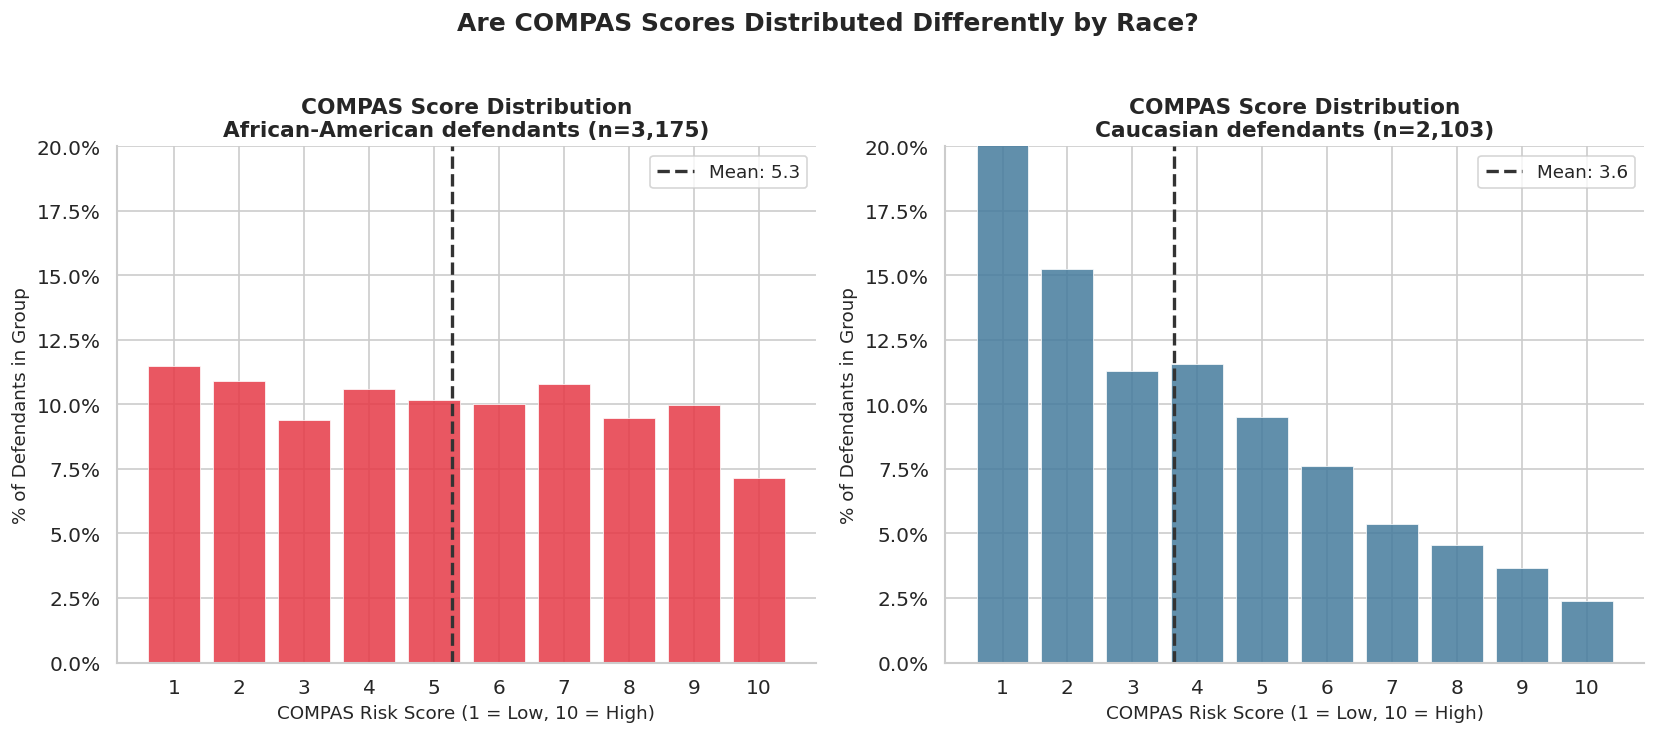

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = {"African-American": "#e63946", "Caucasian": "#457b9d"}

for ax, race in zip(axes, ["African-American", "Caucasian"]):
    subset = df_binary[df_binary["race"] == race]
    # Normalize to percentage of each group instead of raw counts
    pcts = subset["compas_score"].value_counts(normalize=True).sort_index() * 100
    ax.bar(pcts.index, pcts.values,
           color=colors[race], alpha=0.85, edgecolor="white", linewidth=0.5)
    ax.set_title(f"COMPAS Score Distribution\n{race} defendants (n={len(subset):,})",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("COMPAS Risk Score (1 = Low, 10 = High)", fontsize=11)
    ax.set_ylabel("% of Defendants in Group", fontsize=11)  # updated label
    ax.set_xticks(range(1, 11))
    ax.set_ylim(0, 20)  # fixed y-axis so both charts are directly comparable
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    mean_score = subset["compas_score"].mean()
    ax.axvline(mean_score, color="#333333", linestyle="--", linewidth=2,
               label=f"Mean: {mean_score:.1f}")
    ax.legend(fontsize=11)
    sns.despine(ax=ax)

plt.suptitle("Are COMPAS Scores Distributed Differently by Race?",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

**Question:** Describe what you see. Does the score distribution look different between Black and white defendants? What does the shape of each distribution tell you about how COMPAS classifies each group?

**Ans:**

**Step 3:** Compare actual recidivism rates vs. predicted risk scores

A fair algorithm should score people based on their *actual* likelihood of re-offending, not their race. Let's check: are COMPAS scores equally predictive for both groups?

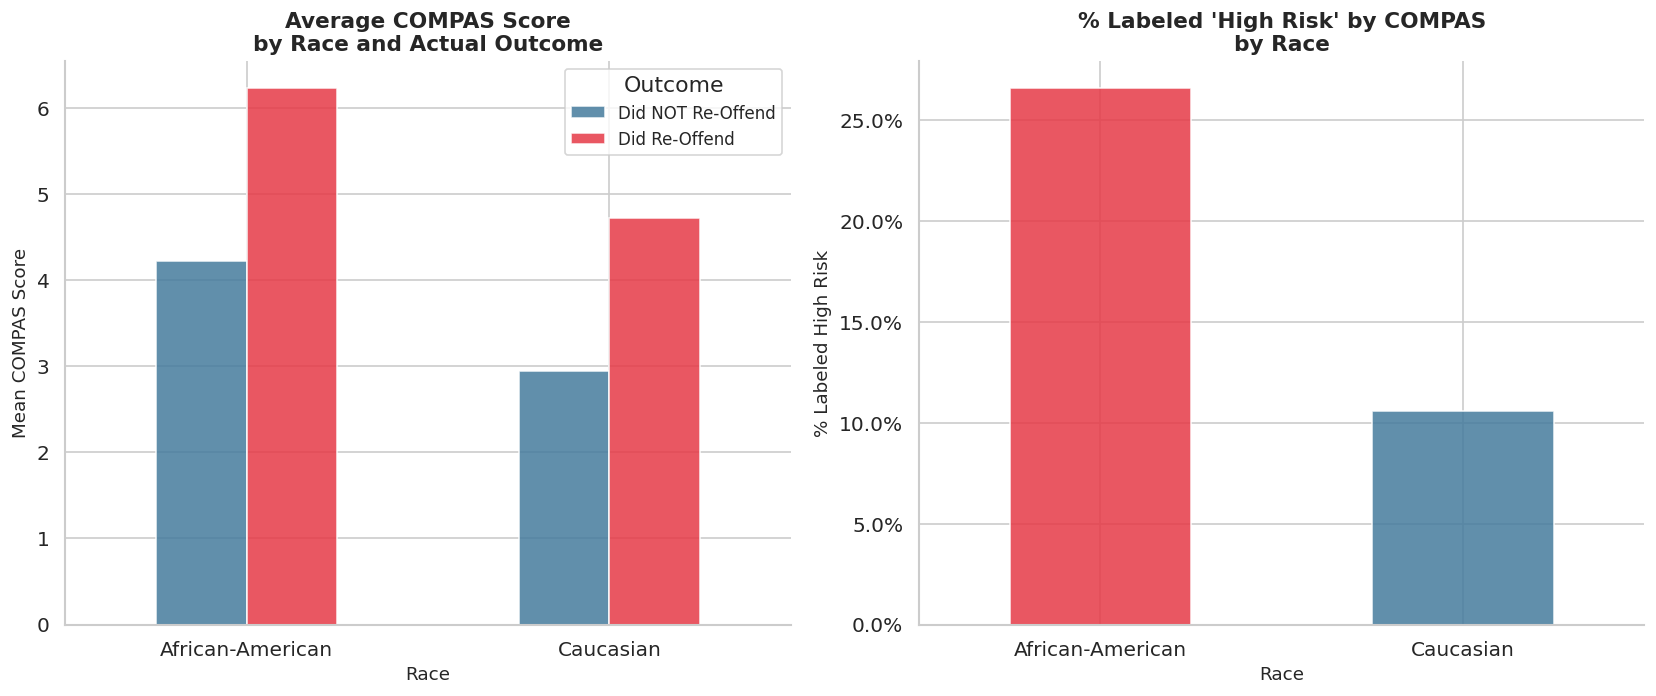

In [ ]:
# Mean COMPAS score vs. actual recidivism rate by race
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left plot: Average COMPAS score by race and actual outcome
pivot_score = df_binary.groupby(["race", "recidivated"])["compas_score"].mean().unstack()
pivot_score.columns = ["Did NOT Re-Offend", "Did Re-Offend"]
pivot_score.plot(kind="bar", ax=axes[0], color=["#457b9d", "#e63946"],
                 alpha=0.85, edgecolor="white", rot=0)
axes[0].set_title("Average COMPAS Score\nby Race and Actual Outcome",
                  fontsize=13, fontweight="bold")
axes[0].set_xlabel("Race", fontsize=11)
axes[0].set_ylabel("Mean COMPAS Score", fontsize=11)
axes[0].legend(title="Outcome", fontsize=10)
sns.despine(ax=axes[0])

# Right plot: High-risk label rate by race
df_binary["high_risk"] = (df_binary["score_text"] == "High").astype(int)
high_risk_rate = df_binary.groupby("race")["high_risk"].mean() * 100
high_risk_rate.plot(kind="bar", ax=axes[1],
                    color=["#e63946", "#457b9d"], alpha=0.85, edgecolor="white", rot=0)
axes[1].set_title("% Labeled 'High Risk' by COMPAS\nby Race",
                  fontsize=13, fontweight="bold")
axes[1].set_xlabel("Race", fontsize=11)
axes[1].set_ylabel("% Labeled High Risk", fontsize=11)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

**Step 4:** Age and prior record distributions by race.

COMPAS claims to base its scores on age and criminal history, not race. In order to determine whether the algorithm is implicitly storing racial patterns, let's examine whether these "neutral" inputs are distributed differently among racial groups.

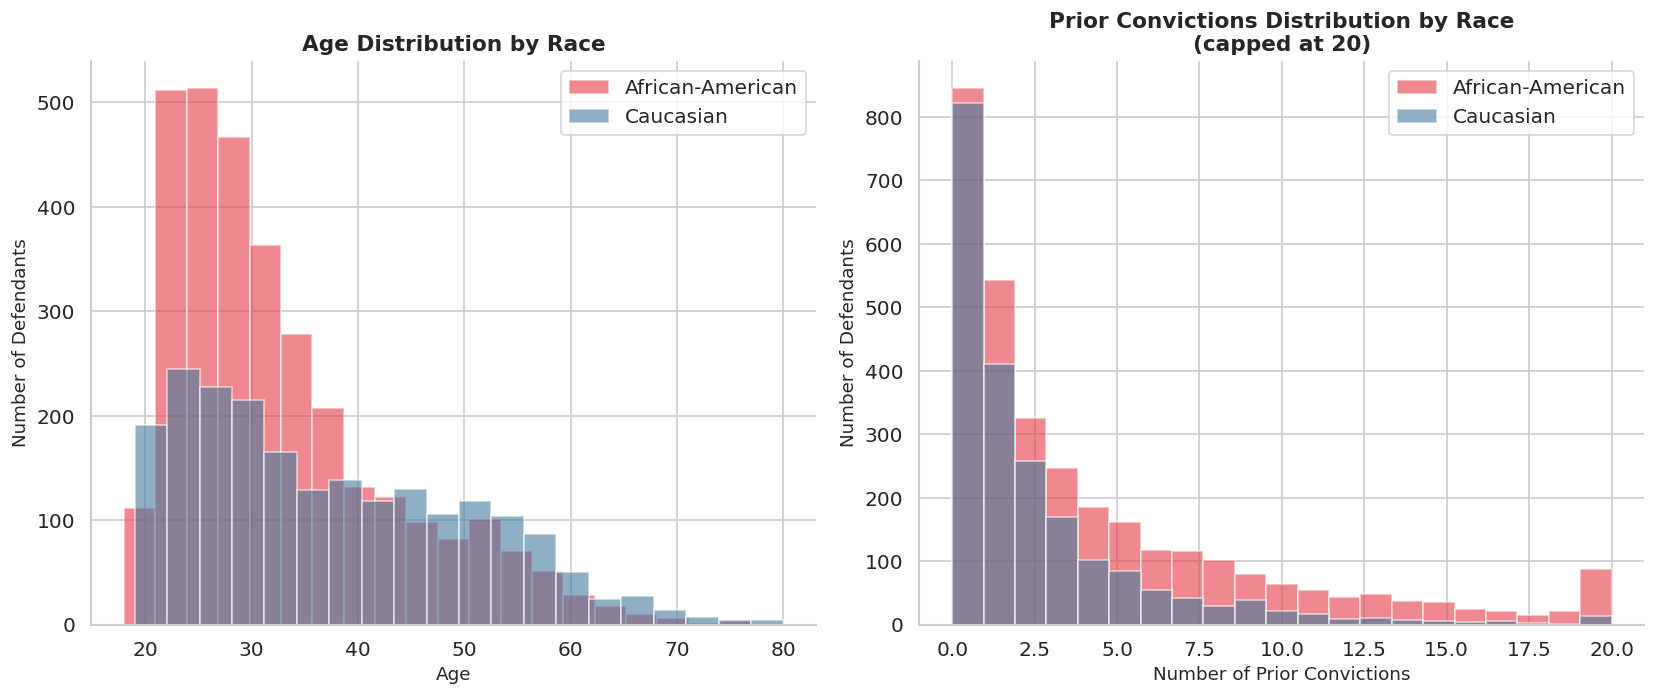


Mean age by race:
race
African-American    32.4
Caucasian           37.5
Name: age, dtype: float64

Mean prior convictions by race:
race
African-American    4.24
Caucasian           2.29
Name: priors_count, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Age distribution
for race, color in colors.items():
    subset = df_binary[df_binary["race"] == race]
    axes[0].hist(subset["age"], bins=20, alpha=0.6, label=race,
                 color=color, edgecolor="white")
axes[0].set_title("Age Distribution by Race", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Age", fontsize=11)
axes[0].set_ylabel("Number of Defendants", fontsize=11)
axes[0].legend()
sns.despine(ax=axes[0])

# Prior convictions distribution (cap at 20 for readability)
priors_capped = df_binary.copy()
priors_capped["priors_count"] = priors_capped["priors_count"].clip(0, 20)
for race, color in colors.items():
    subset = priors_capped[priors_capped["race"] == race]
    axes[1].hist(subset["priors_count"], bins=21, alpha=0.6, label=race,
                 color=color, edgecolor="white")
axes[1].set_title("Prior Convictions Distribution by Race\n(capped at 20)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Number of Prior Convictions", fontsize=11)
axes[1].set_ylabel("Number of Defendants", fontsize=11)
axes[1].legend()
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

print("\nMean age by race:")
print(df_binary.groupby("race")["age"].mean().round(1))
print("\nMean prior convictions by race:")
print(df_binary.groupby("race")["priors_count"].mean().round(2))

**Question:** COMPAS uses age and prior convictions as key inputs. You can see these are distributed differently across racial groups. Does this mean the algorithm is being *racist*, or is it faithfully reflecting real differences in the data? Can it be both at the same time? What does this tell us about the concept of a "neutral" algorithm?

**Ans:**

# **Milestone 5: Building the blind model**
---
A common first instinct when building a "fair" algorithm is to simply **remove race from the input features**. If the model never sees race, it can't discriminate, right?

In this milestone we test this assumption.

**Step 1:** Define features and target.

We deliberately exclude `race` and `race_binary` from the model inputs. We also exclude `compas_score` and `score_text` (those are COMPAS's predictions, not our inputs) and `name`/`id`.

| Feature | Why we include it |
|---|---|
| `age` | Younger defendants statistically have higher recidivism rates |
| `priors_count` | Number of prior charges is a strong predictor |
| `charge_felony` | Felony charges are more serious than misdemeanors |
| `juv_fel_count` | Juvenile felony history |
| `juv_misd_count` | Juvenile misdemeanor history |

In [ ]:
# Define features and target — RACE IS EXCLUDED
FEATURES = ["age", "priors_count", "charge_felony",
            "juv_fel_count", "juv_misd_count"]
TARGET = "recidivated"

X = df_binary[FEATURES]
y = df_binary[TARGET]

# Keep race for evaluation (but NOT for training)
race_col = df_binary["race"]

print("Feature matrix shape:", X.shape)
print("Target distribution:")
print(y.value_counts(normalize=True).round(3))

Feature matrix shape: (5278, 5)
Target distribution:
recidivated
0    0.53
1    0.47
Name: proportion, dtype: float64


**Step 2:** Split into training and test sets.

We use an 80/20 split and set a random seed (`random_state=42`) so results are reproducible.

In [ ]:
X_train, X_test, y_train, y_test, race_train, race_test = train_test_split(
    X, y, race_col,
    test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {len(X_train):,} defendants")
print(f"Test set:     {len(X_test):,} defendants")
print(f"\nRace split in test set:")
print(race_test.value_counts())

Training set: 4,222 defendants
Test set:     1,056 defendants

Race split in test set:
race
African-American    627
Caucasian           429
Name: count, dtype: int64


**Step 3:** Train a Decision Tree classifier.

We use a Decision Tree because it is interpretable. In Milestone 7 we will be able to see exactly how it makes decisions. We limit the depth to 5 to prevent overfitting.

**Remember:** A **Decision Tree** learns a sequence of yes/no rules from the training data. For example: "If priors_count > 3 AND age < 25, predict re-offend."

In [ ]:
# Train the Decision Tree (no race features)
model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)

# Evaluate on test set
y_pred = model.predict(X_test)
overall_accuracy = accuracy_score(y_test, y_pred)

print(f"Overall model accuracy: {overall_accuracy:.1%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
                            target_names=["No Recidivism", "Recidivism"]))

Overall model accuracy: 65.8%

Classification Report:
               precision    recall  f1-score   support

No Recidivism       0.67      0.70      0.69       559
   Recidivism       0.65      0.61      0.63       497

     accuracy                           0.66      1056
    macro avg       0.66      0.66      0.66      1056
 weighted avg       0.66      0.66      0.66      1056



**Step 4:** Accuracy by race

Our model was trained without race. But watch what happens when we check accuracy *separately* for Black and white defendants.

In [ ]:
# Evaluate accuracy separately for each racial group
print("Accuracy by Race\n")

for race in ["African-American", "Caucasian"]:
    mask = race_test == race
    acc = accuracy_score(y_test[mask], y_pred[mask])
    n = mask.sum()
    print(f"{race:<22}: {acc:.1%}  (n={n})")

print("\n Even though race was not a feature, does accuracy differ by group?")

Accuracy by Race

African-American      : 66.7%  (n=627)
Caucasian             : 64.6%  (n=429)

 Even though race was not a feature, does accuracy differ by group?


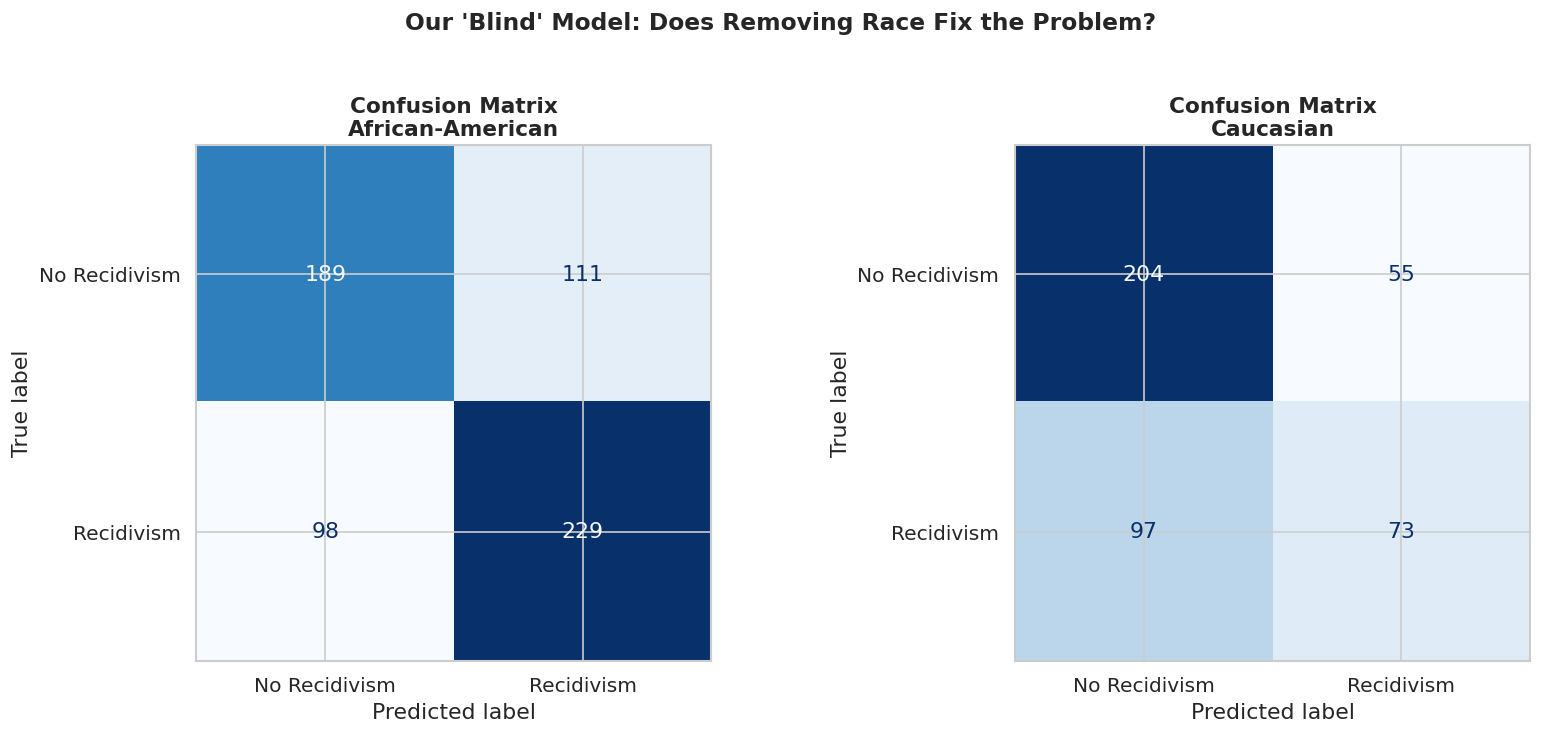

In [ ]:
# Visualize predictions by race
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, race in zip(axes, ["African-American", "Caucasian"]):
    mask = race_test == race
    cm = confusion_matrix(y_test[mask], y_pred[mask])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=["No Recidivism", "Recidivism"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"Confusion Matrix\n{race}", fontsize=13, fontweight="bold")

plt.suptitle("Our 'Blind' Model: Does Removing Race Fix the Problem?",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# TODO: Re-train the model with a different max_depth (try 3 or 7).
# Does a shallower or deeper tree reduce the accuracy gap between groups?

### YOUR CODE HERE ###

# **Milestone 6: The Fairness Audit**
---
Accuracy alone tells us almost nothing about fairness. A model can be 80% accurate *overall* while systematically failing one group. In this milestone we compute formal fairness metrics, reproduce ProPublica's findings, and encounter the **Impossibility Theorem**, one of the most important results in algorithmic fairness.

**Step 1:** Understand the fairness metrics.

All four fairness metrics below involve comparing what the model predicts across racial groups:

| Metric | Formula | What it measures |
|---|---|---|
| **Demographic Parity** | P(Ŷ=1\|A=a) = P(Ŷ=1\|A=b) | Are positive predictions equally likely for both groups? |
| **False Positive Rate (FPR)** | P(Ŷ=1\|Y=0, A=a) = P(Ŷ=1\|Y=0, A=b) | Are innocent people equally likely to be mislabeled as guilty? |
| **False Negative Rate (FNR)** | P(Ŷ=0\|Y=1, A=a) = P(Ŷ=0\|Y=1, A=b) | Are actual re-offenders equally likely to be missed? |
| **Equalized Odds** | FPR *and* FNR equal across groups | Both types of errors are balanced |

In [ ]:
def fairness_metrics(y_true, y_pred, race_series):
    """Compute fairness metrics for each racial group."""
    results = {}
    for race in ["African-American", "Caucasian"]:
        mask = race_series == race
        yt = y_true[mask]
        yp = y_pred[mask]

        tn, fp, fn, tp = confusion_matrix(yt, yp).ravel()

        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0   # false positive rate
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0   # false negative rate
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0   # true positive rate
        ppv = tp / (tp + fp) if (tp + fp) > 0 else 0   # precision
        pred_pos_rate = yp.mean()                        # demographic parity

        results[race] = {
            "n": mask.sum(),
            "Pred. Positive Rate (Dem. Parity)": pred_pos_rate,
            "False Positive Rate (FPR)": fpr,
            "False Negative Rate (FNR)": fnr,
            "True Positive Rate (TPR)": tpr,
            "Precision (PPV)": ppv,
        }
    return pd.DataFrame(results).T

metrics_df = fairness_metrics(y_test, y_pred, race_test)
print("Fairness Metrics: Our 'Blind' Decision Tree\n")
print(metrics_df.round(3).to_string())

Fairness Metrics: Our 'Blind' Decision Tree

                      n  Pred. Positive Rate (Dem. Parity)  False Positive Rate (FPR)  False Negative Rate (FNR)  True Positive Rate (TPR)  Precision (PPV)
African-American  627.0                              0.542                      0.370                      0.300                     0.700            0.674
Caucasian         429.0                              0.298                      0.212                      0.571                     0.429            0.570


**Step 2:** Visualize the fairness gaps.

Numbers in a table are hard to read. Let's visualize the key metrics side by side.

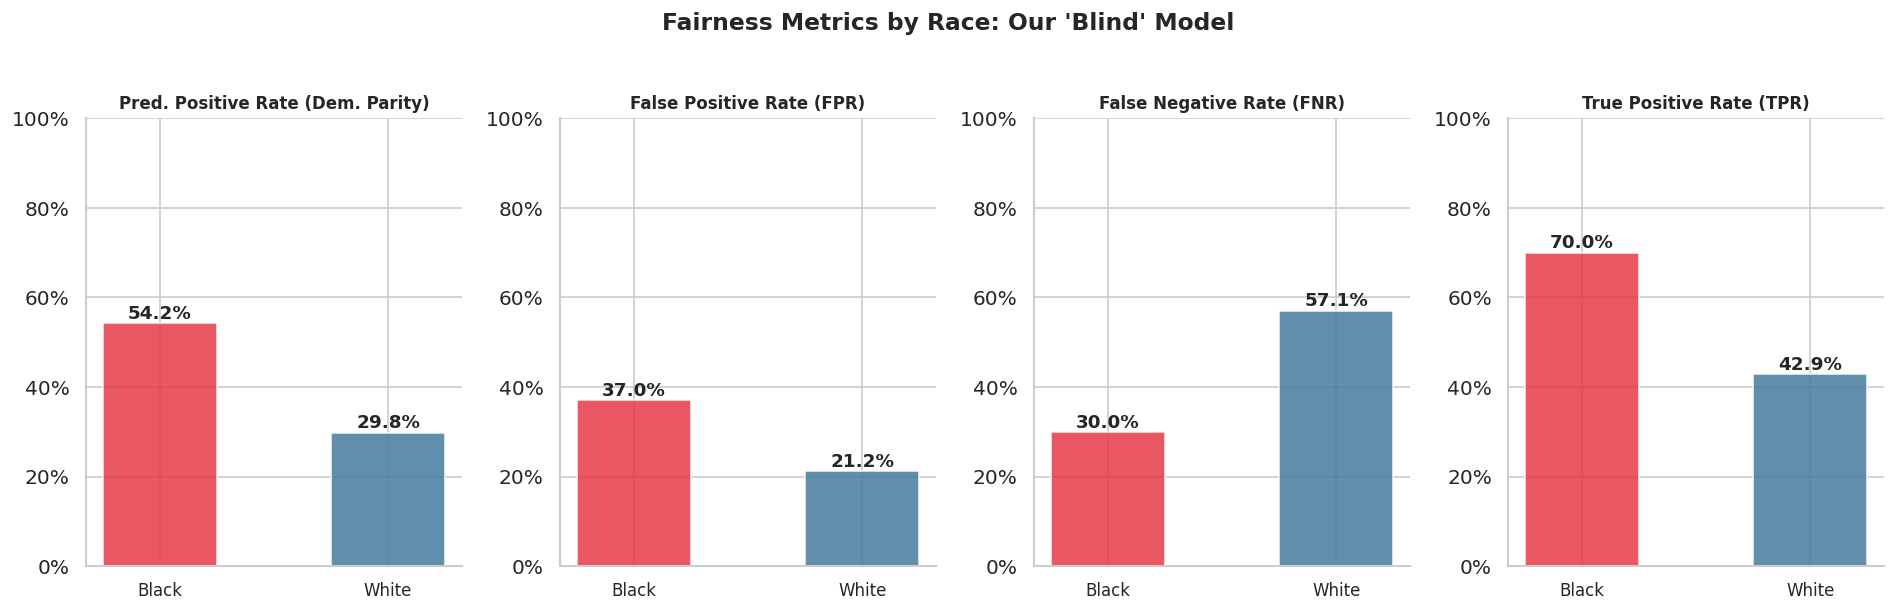

In [ ]:
metric_cols = [
    "Pred. Positive Rate (Dem. Parity)",
    "False Positive Rate (FPR)",
    "False Negative Rate (FNR)",
    "True Positive Rate (TPR)"
]

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

race_colors = {"African-American": "#e63946", "Caucasian": "#457b9d"}

for ax, metric in zip(axes, metric_cols):
    values = metrics_df[metric]
    bars = ax.bar(values.index, values.values,
                  color=[race_colors[r] for r in values.index],
                  alpha=0.85, edgecolor="white", width=0.5)
    for bar, val in zip(bars, values.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{val:.1%}", ha="center", fontsize=11, fontweight="bold")
    ax.set_title(metric, fontsize=10, fontweight="bold")
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_xticklabels(["Black", "White"], fontsize=10)
    sns.despine(ax=ax)

plt.suptitle("Fairness Metrics by Race: Our 'Blind' Model",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

**Step 3:** Now audit COMPAS itself & reproduce ProPublica's findings

So far we have been evaluating *our model*. But COMPAS is the one actually being used in courts. Let's apply the same fairness metrics to COMPAS's own scores.

In [ ]:
# COMPAS uses score >= 5 as the boundary for "Medium" and "High" risk
# We treat score >= 5 as a positive prediction ("will re-offend")
compas_pred_all = (df_binary["compas_score"] >= 5).astype(int)

# Align with our test set
compas_pred_test = compas_pred_all.loc[X_test.index]

print("=== Fairness Metrics: COMPAS Scores ===\n")
compas_metrics = fairness_metrics(y_test, compas_pred_test, race_test)
print(compas_metrics.round(3).to_string())

=== Fairness Metrics: COMPAS Scores ===

                      n  Pred. Positive Rate (Dem. Parity)  False Positive Rate (FPR)  False Negative Rate (FNR)  True Positive Rate (TPR)  Precision (PPV)
African-American  627.0                              0.552                      0.380                      0.291                     0.709            0.671
Caucasian         429.0                              0.336                      0.247                      0.529                     0.471            0.556


In [ ]:
# Side-by-side comparison: Our model vs. COMPAS
print("\n Comparison: False Positive Rate")
print(f"{'':30} {'Black':>12} {'White':>12} {'Gap':>10}")
print("-"*65)

for label, metrics in [("Our 'Blind' Model", metrics_df),
                        ("COMPAS Algorithm", compas_metrics)]:
    b = metrics.loc["African-American", "False Positive Rate (FPR)"]
    w = metrics.loc["Caucasian", "False Positive Rate (FPR)"]
    print(f"{label:<30} {b:>11.1%} {w:>11.1%} {(b-w):>+10.1%}")

print("\n(ProPublica's published numbers: Black 44.9%, White 23.5% for COMPAS high-risk label)")


 Comparison: False Positive Rate
                                      Black        White        Gap
-----------------------------------------------------------------
Our 'Blind' Model                    37.0%       21.2%     +15.8%
COMPAS Algorithm                     38.0%       24.7%     +13.3%

(ProPublica's published numbers: Black 44.9%, White 23.5% for COMPAS high-risk label)


**Step 4:** The Impossibility Theorem.

Here's where things get philosophically hard. COMPAS's developer (Northpointe) responded to ProPublica by arguing that their algorithm WAS fair because it had equal **calibration**. If COMPAS says you're "high risk," you're equally likely to re-offend regardless of your race.

Both sides were correct. And yet both versions of "fair" cannot exist at the same time.

**Theorem (Kleinberg et al., 2016):** You cannot simultaneously achieve:
1. **Calibration** : predicted probabilities match actual rates per group
2. **Equal FPR**: equal false positive rates across groups
3. **Equal FNR**:  equal false negative rates across groups
...unless *base rates are equal across groups*, which they are not.

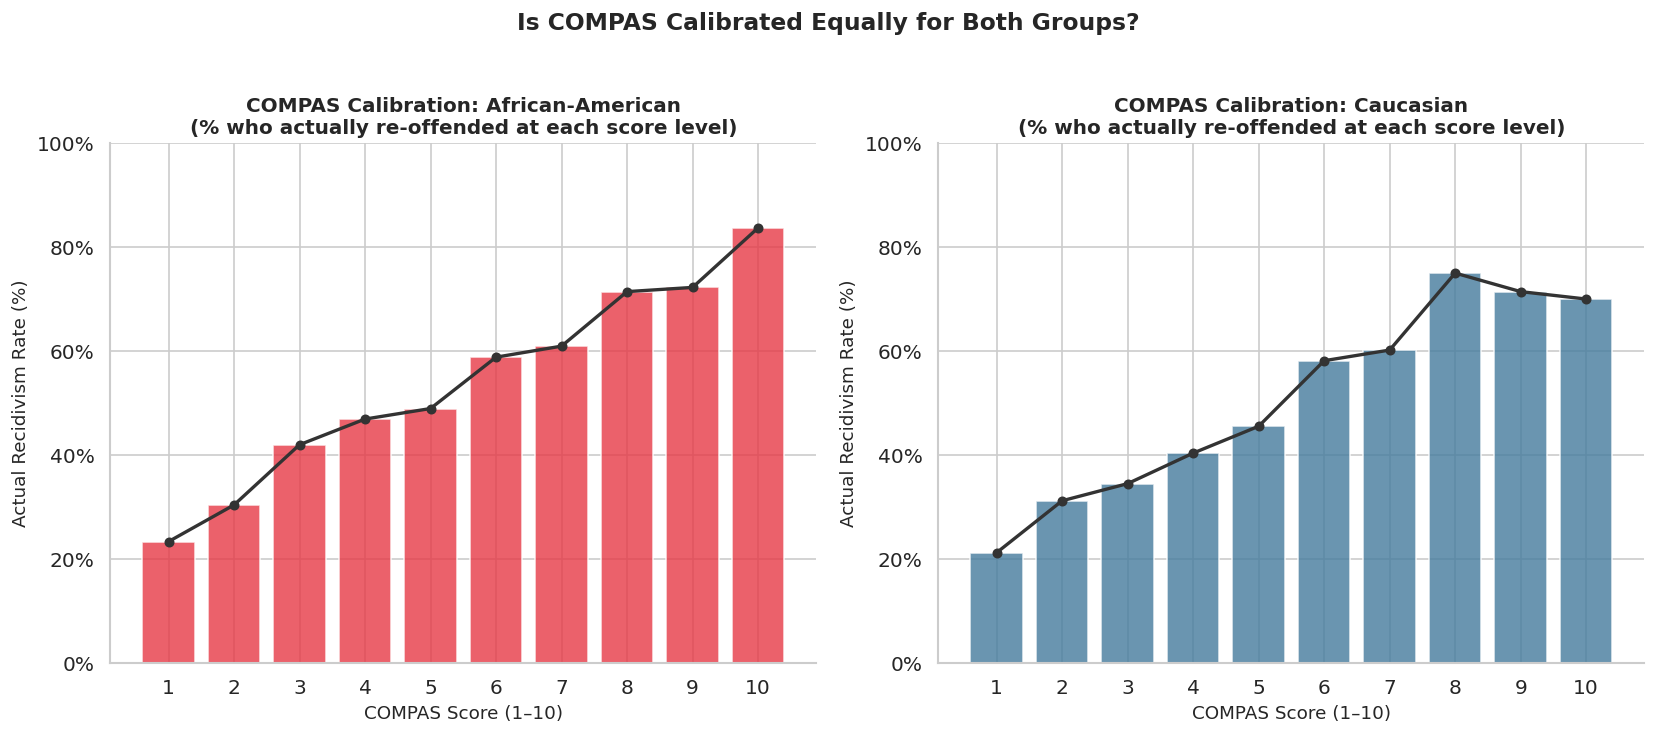

In [ ]:
# Show the calibration of COMPAS scores by race
# For each score level, what fraction actually re-offended?

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, race in zip(axes, ["African-American", "Caucasian"]):
    subset = df_binary[df_binary["race"] == race]
    calib = subset.groupby("compas_score")["recidivated"].agg(["mean", "count"])

    ax.bar(calib.index, calib["mean"] * 100,
           color=race_colors[race], alpha=0.8, edgecolor="white")
    ax.plot(calib.index, calib["mean"] * 100, "o-",
            color="#333333", markersize=5, linewidth=2)
    ax.set_title(f"COMPAS Calibration: {race}\n"
                 f"(% who actually re-offended at each score level)",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("COMPAS Score (1–10)", fontsize=11)
    ax.set_ylabel("Actual Recidivism Rate (%)", fontsize=11)
    ax.set_xticks(range(1, 11))
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    sns.despine(ax=ax)

plt.suptitle("Is COMPAS Calibrated Equally for Both Groups?",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

**Question:** Northpointe said COMPAS was fair because it was calibrated. ProPublica said it was unfair because it had unequal false positive rates. Are both sides telling the truth? Who do you agree with, and why? Is there a third option they are both missing?


# **Milestone 7: Open the Black Box - Explainability (XAI)**
---
We know our model is biased. But *why* does it make the predictions it does? Explainability tools let us look inside a model and attribute each prediction to specific input features. This is not just academic curiosity. GDPR's "right to explanation" requires that any automated decision affecting a person must be explainable to them.

**Step 1:** What is SHAP?

**SHAP (SHapley Additive exPlanations)** answers the question: *"How much did each feature contribute to this specific prediction?"*

It comes from cooperative game theory. Imagine the features as "players" on a team, and the prediction as the "prize." SHAP fairly distributes credit (or blame) for the final prediction to each feature.

Formally:

$$f(x) = E[f(X)] + \sum_{i=1}^{p} \phi_i(x)$$

Where:
- $E[f(X)]$ is the model's average prediction (the baseline)
- $\phi_i(x)$ is SHAP value for feature $i$ — its "fair share" of the deviation from baseline

**Positive SHAP value** → feature pushed the prediction *toward* re-offending  
**Negative SHAP value** → feature pushed the prediction *away* from re-offending

**Step 2:** Compute SHAP values for our Decision Tree.

In [ ]:
# Compute SHAP values using TreeExplainer (fast and exact for tree models)
explainer = shap.TreeExplainer(model)
shap_explanation = explainer(X_test)   # new API → Explanation object

# shape is (n_samples, n_features, n_classes) — we want class 1
shap_vals_recid = shap_explanation.values[:, :, 1]

print(f"SHAP values shape: {shap_vals_recid.shape}")
print(f"Expected:          ({len(X_test)}, {len(FEATURES)})")
print(f"\nFeatures: {FEATURES}")

SHAP values shape: (1056, 5)
Expected:          (1056, 5)

Features: ['age', 'priors_count', 'charge_felony', 'juv_fel_count', 'juv_misd_count']


**Step 3:** What drives predictions overall?

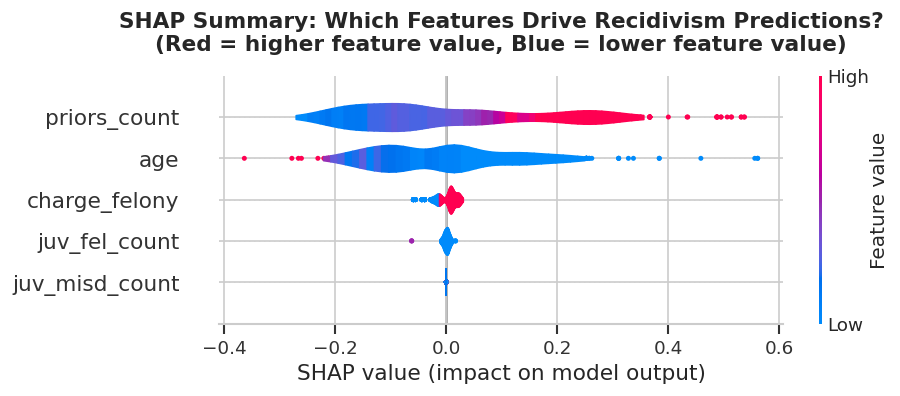

In [ ]:
# Beeswarm plot: shows SHAP value distribution for every feature and every defendant
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals_recid, X_test, feature_names=FEATURES,
                  show=False, plot_type="violin")
plt.title("SHAP Summary: Which Features Drive Recidivism Predictions?\n"
          "(Red = higher feature value, Blue = lower feature value)",
          fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

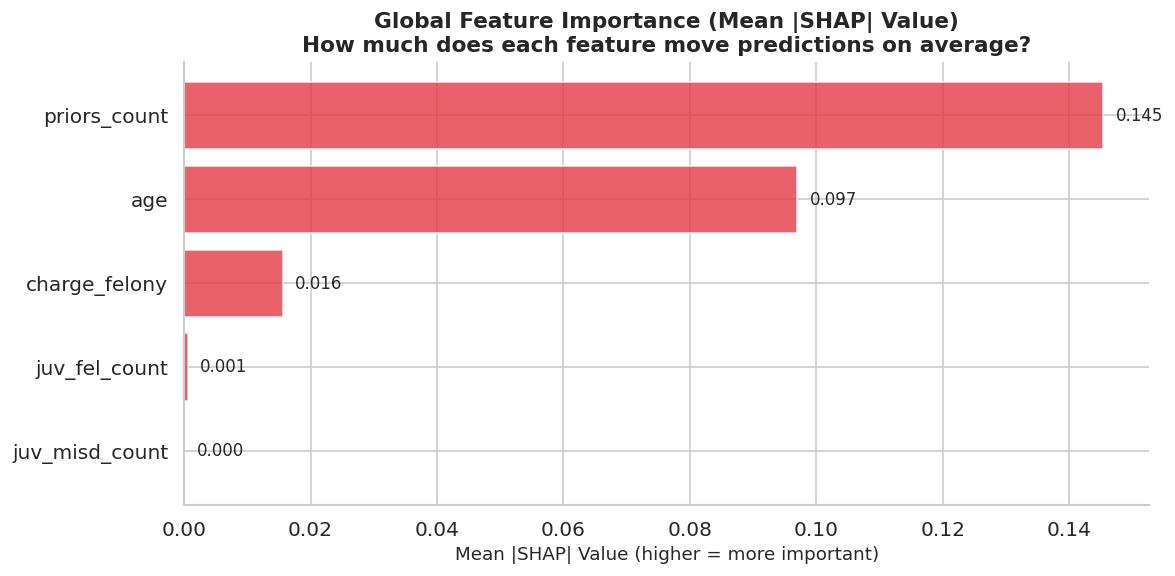

In [ ]:
# Bar chart: mean absolute SHAP value per feature (overall importance)
mean_shap = np.abs(shap_vals_recid).mean(axis=0)
importance_df = pd.DataFrame({
    "Feature": FEATURES,
    "Mean |SHAP|": mean_shap
}).sort_values("Mean |SHAP|", ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(importance_df["Feature"], importance_df["Mean |SHAP|"],
               color="#e63946", alpha=0.8, edgecolor="white")
for bar, val in zip(bars, importance_df["Mean |SHAP|"]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=10)
ax.set_title("Global Feature Importance (Mean |SHAP| Value)\n"
             "How much does each feature move predictions on average?",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Mean |SHAP| Value (higher = more important)", fontsize=11)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

**Question:** Which feature has the *highest* impact on predictions? Does this surprise you?

**Ans:**

**Step 4:** Explain a *single* defendant's prediction

Global explanations tell us what the model cares about in general. Local explanations tell us *why* the model made a specific decision about one person. This is what GDPR's "right to explanation" is about.

In [ ]:
# Find a Black defendant wrongly predicted to re-offend (false positive)
false_positives_black = X_test[
    (y_pred == 1) &           # Model predicted re-offend
    (y_test == 0) &           # Actually did NOT re-offend
    (race_test == "African-American")
]

if len(false_positives_black) > 0:
    idx = false_positives_black.index[0]
    defendant = X_test.loc[idx]
    pos = X_test.index.get_loc(idx)

    print("Wrongly Predicted Defendant (False Positive - Black)")
    print(defendant.to_frame(name="Value").to_string())
    print(f"\nModel prediction: RE-OFFEND (1)")
    print(f"Actual outcome:   DID NOT RE-OFFEND (0)")
    print(f"\nSHAP values for this defendant:")
    for feat, sv in zip(FEATURES, shap_vals_recid[pos]):
        direction = "↑ toward recidivism" if sv > 0 else "↓ away from recidivism"
        print(f"  {feat:<20}: {sv:+.3f}  {direction}")

Wrongly Predicted Defendant (False Positive - Black)
                Value
age                31
priors_count        5
charge_felony       1
juv_fel_count       0
juv_misd_count      0

Model prediction: RE-OFFEND (1)
Actual outcome:   DID NOT RE-OFFEND (0)

SHAP values for this defendant:
  age                 : +0.006  ↑ toward recidivism
  priors_count        : +0.055  ↑ toward recidivism
  charge_felony       : +0.008  ↑ toward recidivism
  juv_fel_count       : +0.000  ↑ toward recidivism
  juv_misd_count      : +0.000  ↓ away from recidivism


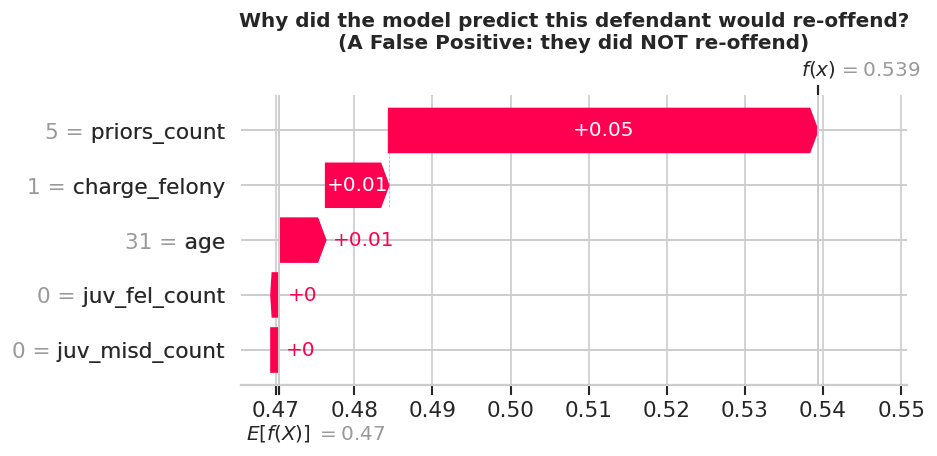

In [ ]:
# Waterfall plot for this defendant
pos = X_test.index.get_loc(false_positives_black.index[0])

shap.waterfall_plot(
    shap.Explanation(
        values=shap_vals_recid[pos],
        base_values=shap_explanation.base_values[pos, 1],
        data=X_test.iloc[pos],
        feature_names=FEATURES
    ),
    show=False
)
plt.title("Why did the model predict this defendant would re-offend?\n(A False Positive: they did NOT re-offend)",
          fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# TODO: Find a false positive among WHITE defendants and display their waterfall plot.
# Do the explanations look different? Which features drove the wrong prediction?

#false_positives_white = X_test
    ### YOUR CODE HERE: filter for white defendants who were false positives ###

# Then plot the waterfall for the first one
### YOUR CODE HERE ###

**Question:** the explanations for the wrongly-convicted Black defendant vs. the wrongly-convicted white defendant. Do the same features drive both false positives?

**Ans:**

# **Milestone 8: The Model Card**
---
You have now built, audited, and explained a recidivism prediction model. The final step in responsible AI development is **documentation**. A **Model Card** is a short document that describes what a model does, how it performs, who it might harm, and how it should (and shouldn't) be used.

Major AI labs (Google, Anthropic, Hugging Face) now publish model cards for their systems. The EU AI Act and GDPR increasingly *require* them. Writing one forces you to be honest about what you built.

**Step 1:** your audit results into one final summary

In [ ]:
print("=" * 55)
print("  COMPAS RECIDIVISM MODEL — AUDIT SUMMARY REPORT")
print("=" * 55)

print("\n Dataset")
print(f"  Total defendants analyzed: {len(df_binary):,}")
for r in ["African-American","Caucasian"]:
    n = (df_binary["race"]==r).sum()
    print(f"  {r}: {n:,} ({n/len(df_binary):.1%})")

print("\n Model Performance (Our Decision Tree, test set)")
print(f"  Overall Accuracy:  {accuracy_score(y_test, y_pred):.1%}")
print(f"  African-American:  {accuracy_score(y_test[race_test=='African-American'], y_pred[race_test=='African-American']):.1%}")
print(f"  Caucasian:         {accuracy_score(y_test[race_test=='Caucasian'], y_pred[race_test=='Caucasian']):.1%}")

print("\n Fairness Metrics — False Positive Rate (our model)")
fpr_b = metrics_df.loc["African-American","False Positive Rate (FPR)"]
fpr_w = metrics_df.loc["Caucasian","False Positive Rate (FPR)"]
print(f"  African-American:  {fpr_b:.1%}")
print(f"  Caucasian:         {fpr_w:.1%}")
print(f"  Gap:               {fpr_b - fpr_w:+.1%}  {' Significant bias' if abs(fpr_b-fpr_w)>0.05 else '✅ Within 5%'}")

print("\n Top 3 Features by SHAP Importance")
importance_sorted = importance_df.sort_values("Mean |SHAP|", ascending=False)
for _, row in importance_sorted.head(3).iterrows():
    print(f"  {row['Feature']:<20}: {row['Mean |SHAP|']:.4f}")

print("\n" + "=" * 55)

  COMPAS RECIDIVISM MODEL — AUDIT SUMMARY REPORT

 Dataset
  Total defendants analyzed: 5,278
  African-American: 3,175 (60.2%)
  Caucasian: 2,103 (39.8%)

 Model Performance (Our Decision Tree, test set)
  Overall Accuracy:  65.8%
  African-American:  66.7%
  Caucasian:         64.6%

 Fairness Metrics — False Positive Rate (our model)
  African-American:  37.0%
  Caucasian:         21.2%
  Gap:               +15.8%   Significant bias

 Top 3 Features by SHAP Importance
  priors_count        : 0.1454
  age                 : 0.0970
  charge_felony       : 0.0156



**Step 2:** Write your Model Card.

Fill in every *italic placeholder* with your own analysis. Use real numbers from the cells above.

---

## Model Card: Recidivism Risk Prediction

### Model Details
| | |
|---|---|
| **Model type** | Decision Tree Classifier (max_depth=5) |
| **Training data** | COMPAS dataset, Broward County FL (2013–2014) |
| **Target variable** | 2-year recidivism (re-arrest within 2 years) |
| **Intended use** | *[What should this model be used for?]* |
| **Out-of-scope uses** | *[What should this model NOT be used for?]* |

---

### Evaluation Results

| Metric | Overall | African-American | Caucasian | Gap |
|---|---|---|---|---|
| Accuracy | *X%* | *X%* | *X%* | *X%* |
| False Positive Rate | *X%* | *X%* | *X%* | *X%* |
| False Negative Rate | *X%* | *X%* | *X%* | *X%* |

---

### Bias & Fairness Findings

**Finding 1:** *[Describe the most significant fairness gap you found, with numbers.]*

**Finding 2:** *[Describe the Impossibility Theorem result. Which fairness definition did COMPAS satisfy? Which did it violate?]*

**Finding 3:** *[Describe the top SHAP feature and what it means for fairness.]*

---

### Ethical Concerns

**Privacy:** *[This model uses the following sensitive attributes... raising concerns about...]*

**Proxy variables:** *[Even without race as a direct input, the model may encode race through...]*

**Historical bias:** *[The training data reflects historical patterns of... which means...]*

---

### Recommendations

**Should this model be deployed in courts?**

*[Your answer - yes, no, or "only if..." - backed by specific numbers from your audit.]*

---
*Audit completed by: [Your Name] | Date: [Date]*



**Question:** You have seen that removing race does not remove bias, and that different definitions of "fair" are mathematically incompatible. Does this mean algorithmic bias is *unsolvable*? Or does it mean we need to make explicit value choices about what fairness means in each context? In contrast to policymakers, what part should data scientists play in making those decisions?

**Ans:**

<h3 align = 'center' >
Thank you for completing the project!
</h3>

Please submit all materials to the NSDC HQ team at nsdc@nebigdata.org in order to receive a virtual certificate of completion. Do reach out to us if you have any questions or concerns. We are here to help you learn and grow.